In [1]:
# import tensorflow as tf
import tensorflow as tf 
import numpy as np

In [2]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
X = housing.data.values.astype(np.float32)
y = housing.target.values.astype(np.float32)
print(f'Features: {housing.feature_names}')
print(f'Shape: X={X.shape} | y={y.shape}')
print(f'Target range: {y.min():.2f} - {y.max():.2f} ($100k)')

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Shape: X=(20640, 8) | y=(20640,)
Target range: 0.15 - 5.00 ($100k)


In [3]:
from sklearn.model_selection import train_test_split
X_temp,X_test,y_temp,y_test = train_test_split(X,y,test_size=0.15,random_state=42)
X_train,X_val,y_train,y_val = train_test_split(X_temp,y_temp,test_size=0.15,random_state=42)

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
print(f'\nTrain: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')


Train: 14912 | Val: 2632 | Test: 3096


In [5]:
from tensorflow import keras
def build_house_model(input_dim):
    inputs = keras.Input(shape=(input_dim,), name='features')

    X = keras.layers.Dense(256)(inputs)
    X = keras.layers.BatchNormalization()(X)
    X = keras.layers.Activation('relu')(X)
    X = keras.layers.Dropout(0.2)(X)

    X = keras.layers.Dense(128)(X)
    X = keras.layers.BatchNormalization()(X)
    X = keras.layers.Activation('relu')(X)
    X = keras.layers.Dropout(0.2)(X)

    X = keras.layers.Dense(64)(X)
    X = keras.layers.BatchNormalization()(X)
    X = keras.layers.Activation('relu')(X)
    X = keras.layers.Dropout(0.1)(X)

    outputs = keras.layers.Dense(1, name='price_output')(X)
    return keras.Model(inputs, outputs, name='HousePriceANN')



In [6]:
model = build_house_model(input_dim=8)
model.summary()

Model: "HousePriceANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ price_output (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,313 (177.00 KB)

 Trainable params: 44,417 (173.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [7]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss = 'mae',
    metrics = ['mae']
)

In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor = 'val_loss',patience=15,
        restore_best_weights=True, verbose=1 #verbose means show me the results at each step
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor = 'val_loss', factor=0.5, patience=7,
        min_1r=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
    'best_house_model.keras', monitor='val_loss',
    save_best_only = True, verbose=0
    )
]

In [9]:
history = model.fit(
    X_train, y_train,
    epochs=200, batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=callbacks, verbose=1
)

Epoch 1/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 1.4697 - mae: 1.4697 - val_loss: 1.4053 - val_mae: 1.4053 - learning_rate: 0.0010
Epoch 2/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.6240 - mae: 0.6240 - val_loss: 0.9748 - val_mae: 0.9748 - learning_rate: 0.0010
Epoch 3/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.5578 - mae: 0.5578 - val_loss: 0.8013 - val_mae: 0.8013 - learning_rate: 0.0010
Epoch 4/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.5300 - mae: 0.5300 - val_loss: 0.6817 - val_mae: 0.6817 - learning_rate: 0.0010
Epoch 5/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.5116 - mae: 0.5116 - val_loss: 0.5953 - val_mae: 0.5953 - learning_rate: 0.0010
Epoch 6/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.5048 - mae: 0.5048 - val_loss: 0.5417 - val_mae: 0.5417 - learning_rate: 0.0010
Epoch 7/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.4875 - mae: 0.4875 - val_loss: 0.5408 - val_mae: 0.5408 - learning_rate: 0.0010
Epoch 

In [10]:
from sklearn.metrics import r2_score
results = model.evaluate(X_test, y_test, verbose=0)
print(f'\n=== TEST RESULTS ===')
print(f'RSE: {results[0]:.4f}')
print(f'RSE: {results[1]:.4f} (${results[1]*100:.0f}k average error)')
y_pred = model.predict(X_test, verbose=0).flatten()
r2 = r2_score(y_test, y_pred)
print(f'R: {r2:.4f} (1.0 = perfect)')


=== TEST RESULTS ===
RSE: 0.4794
RSE: 0.4794 ($48k average error)
R: 0.5843 (1.0 = perfect)


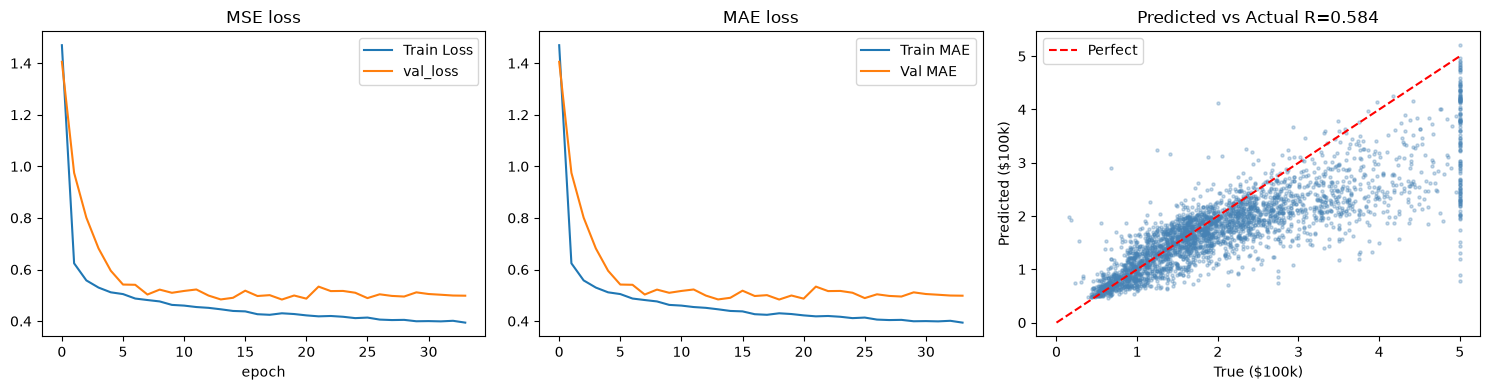

In [11]:
import matplotlib.pyplot as plt 
fig, axes = plt.subplots(1,3, figsize=(15,4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='val_loss')
axes[0].set_title('MSE loss')
axes[0].set_xlabel('epoch')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MAE loss')
axes[1].legend()

axes[2].scatter(y_test, y_pred, alpha=0.3, s=5, color='steelblue')
axes[2].plot([0,5], [0,5], 'r--', label='Perfect')
axes[2].set_xlabel('True ($100k)')
axes[2].set_ylabel('Predicted ($100k)')
axes[2].set_title(f'Predicted vs Actual R={r2:.3f}')
axes[2].legend()
plt.tight_layout()
plt.savefig('House_price_prediction.png', dpi=150)
plt.show()

In [1]:
import tensorflow as tf 